- Adrián Marcelo Garza Morton 598817 & Patricio Dávila Santos 504056
- Inteligencia Artificial 2
- Tarea 4 - Single-Neuron Network with and without PCA
- Dr. Andrés Hernández Gutiérrez
- 5/03/2026
- Universidad de Monterrey
- San Pedro Garza García, Nuevo León, México
- Damos nuestra palabra que hemos realizado esta actividad con integridad académica

La siguiente línea de código es para instalar en la sesión el Ucimlrepo, que nos servirá para el dataset con el que se trabajará. Más adelante se explica a detalle.

In [ ]:
pip install ucimlrepo

**Imports y librerías**

Importo las librerías necesarias para realizar el trabajo. Se requiere manejo de datos con Pandas, visualización con Matplotlib, Seaborn y Plotly, estandarización para PCA, y el dataset que se importa desde `ucimlrepo`, el enlace siendo: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic. Ucimlrepo es una biblioteca de Python oficial del repositorio UCI Machine Learning que permite cargar conjuntos de datos directamente desde su plataforma

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Aquí se va a importar el dataset de Breast Cancer Wisconsin (Diagnostic) desde UCI usando ucimlrepo, el enlace siendo: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic. Este es todo el código que da UCI cuando se le da import.

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

En esta parte se separan las variables del dataset en **X (features)** y **y (target)**.  
La variable **X** contiene todas las características del tumor que se utilizarán para entrenar el modelo, mientras que **y** contiene el diagnóstico que el modelo debe predecir.

También se imprime el **shape** de cada variable para conocer la dimensión de los datos. En este caso, `X` tiene **(569, 30)**, lo que significa que hay **569 observaciones (pacientes)** y **30 variables predictoras**. Por otro lado, `y` tiene **(569, 1)**, lo que indica que hay **569 etiquetas de diagnóstico**, una para cada observación.

Imprimir el `shape` es importante porque permite verificar que el número de muestras en **X** y **y** coincide correctamente antes de entrenar el modelo.

Finalmente, se muestran las primeras 5 filas (`head()`) para visualizar cómo se ven los datos y confirmar que las variables se cargaron correctamente.

In [ ]:
X = breast_cancer_wisconsin_diagnostic.data.features.copy()
y = breast_cancer_wisconsin_diagnostic.data.targets.copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())
display(y.head())


Shape X: (569, 30)
Shape y: (569, 1)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Diagnosis
0,M
1,M
2,M
3,M
4,M


# **1. a)** Descripción del dataset:

El dataset utilizado en esta actividad es Breast Cancer Wisconsin Diagnostic. Este se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic. Este dataset es usado en problemas de clasificación dentro del área de la medicina, específicamente en el diagnóstico de cáncer de mama. Su propósito es apoyar la identificación de tumores como benignos o malignos a partir de características numéricas obtenidas de imágenes digitalizadas de una aspiración con aguja fina (fine needle aspirate) de una masa mamaria. El dominio de aplicación de este dataset es médico, ya que busca resolver un problema de apoyo al diagnóstico clínico.

El dataset incluye una columna llamada ID, pero esta funciona únicamente como identificador del registro y no tiene valor predictivo para el problema.

La variable objetivo (y), o target, es Diagnosis, que indica el tipo de tumor observado. Esta variable es categórica y tiene dos posibles valores: B para benign (benigno) y M para malignant (maligno).

Las variables predictoras (x) son 30 características numéricas continuas, todas relacionadas con propiedades geométricas y de textura del núcleo celular observado en la imagen. Estas son mediciones cuantitativas extraídas directamente de las imágenes, además que describen un aspecto diferente de la forma o estructura del tumor.. Las características base son: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry y fractal dimension.

Radius representa una medida del tamaño del núcleo celular. Texture se relaciona con la variación en los tonos de gris de la imagen. Perimeter y Area describen el contorno y el tamaño de la región analizada. Smoothness mide qué tan uniforme es el borde. Compactness y Concavity reflejan irregularidades en la forma. Concave points cuantifica la cantidad de puntos cóncavos del contorno. Symmetry describe qué tan simétrica es la estructura. Fractal dimension mide la complejidad del borde.

Estas 10 características no aparecen una sola vez, sino que se registran en tres versiones distintas, dando origen a las 30 variables predictoras totales. Las variables con sufijo 1 corresponden al valor medio de cada medición, las variables con sufijo 2 representan el error estándar y las variables con sufijo 3 corresponden al valor más grande observado.

Importamos nuestro dataset desde el directorio local y lo asignamos a la variable `df`. Además, nombramos cada columna como viene en el dataset para mantener consistencia.

In [ ]:
nombres_columnas = ['id', 'diagnostico'] + [f'caracteristica_{i}' for i in range(1, 31)]
df = pd.read_csv('sample_data/wdbc.data', names=nombres_columnas)

Antes de trabajar con el dataset, primero debemos limpiarlo de cualquier columna que no aporte información relevante (en este caso, la columna de `id`) o que contenga datos nulos. Este dataset no contiene datos nulos. Por último, transformamos las variables categóricas a variables cuantitativas; por ejemplo, convertimos letras a números: Maligno (**M**) = 1 y Benigno (**B**) = 0.


In [ ]:
# Eliminamos el 'id' ya que no sirve para predecir
df = df.drop('id', axis=1)

# Convertimos las letras a números: Maligno (M) = 1, Benigno (B) = 0
df['diagnostico'] = df['diagnostico'].map({'M': 1, 'B': 0})

# **EDA**

En esta sección se realiza un análisis exploratorio del dataset para entender mejor la estructura de los datos antes de entrenar el modelo.  
Se incluyen estadísticas descriptivas, distribuciones de variables y análisis de correlación entre características.

In [ ]:
# Summary statistics
display(df.describe())

,diagnostico,caracteristica_1,caracteristica_2,caracteristica_3,caracteristica_4,caracteristica_5,caracteristica_6,caracteristica_7,caracteristica_8,caracteristica_9,...,caracteristica_21,caracteristica_22,caracteristica_23,caracteristica_24,caracteristica_25,caracteristica_26,caracteristica_27,caracteristica_28,caracteristica_29,caracteristica_30
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


La tabla anterior muestra las **estadísticas descriptivas** de todas las variables del dataset, incluyendo el número de observaciones, media, desviación estándar, valores mínimos, máximos y cuartiles.

Podemos observar que el dataset contiene **569 observaciones** y **30 variables predictoras**, además de la variable objetivo `diagnostico`. Las variables presentan rangos y escalas diferentes, por ejemplo algunas características como área o perímetro tienen valores mucho más grandes que otras como smoothness o fractal dimension.

Este análisis permite entender mejor la distribución general de los datos y también justifica el uso posterior de **estandarización**, ya que trabajar con variables en distintas escalas podría afectar el entrenamiento del modelo.

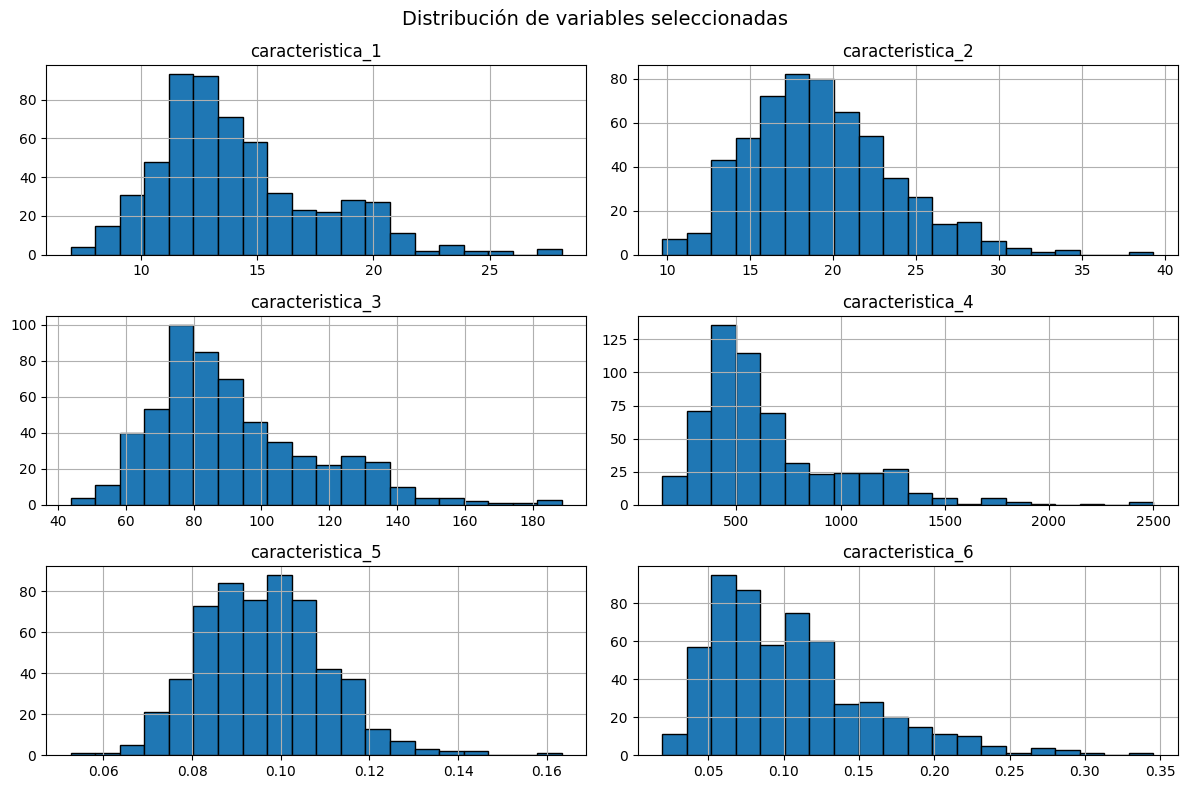

In [ ]:
# Feature distributions - histogramas

columnas_hist = [
    "caracteristica_1",
    "caracteristica_2",
    "caracteristica_3",
    "caracteristica_4",
    "caracteristica_5",
    "caracteristica_6"
]

df[columnas_hist].hist(figsize=(12,8), bins=20, edgecolor="black")

plt.suptitle("Distribución de variables seleccionadas", fontsize=14)
plt.tight_layout()
plt.show()

Los histogramas muestran la distribución de algunas variables del dataset.
Se puede observar que la mayoría de las características presentan una distribución concentrada en ciertos rangos, aunque algunas muestran una ligera asimetría hacia valores más altos.

Esto indica que las variables no siguen exactamente la misma escala ni distribución, lo cual refuerza la necesidad de aplicar estandarización antes de entrenar el modelo. Además, estas gráficas ayudan a entender cómo se comportan los datos y si existen posibles valores extremos.

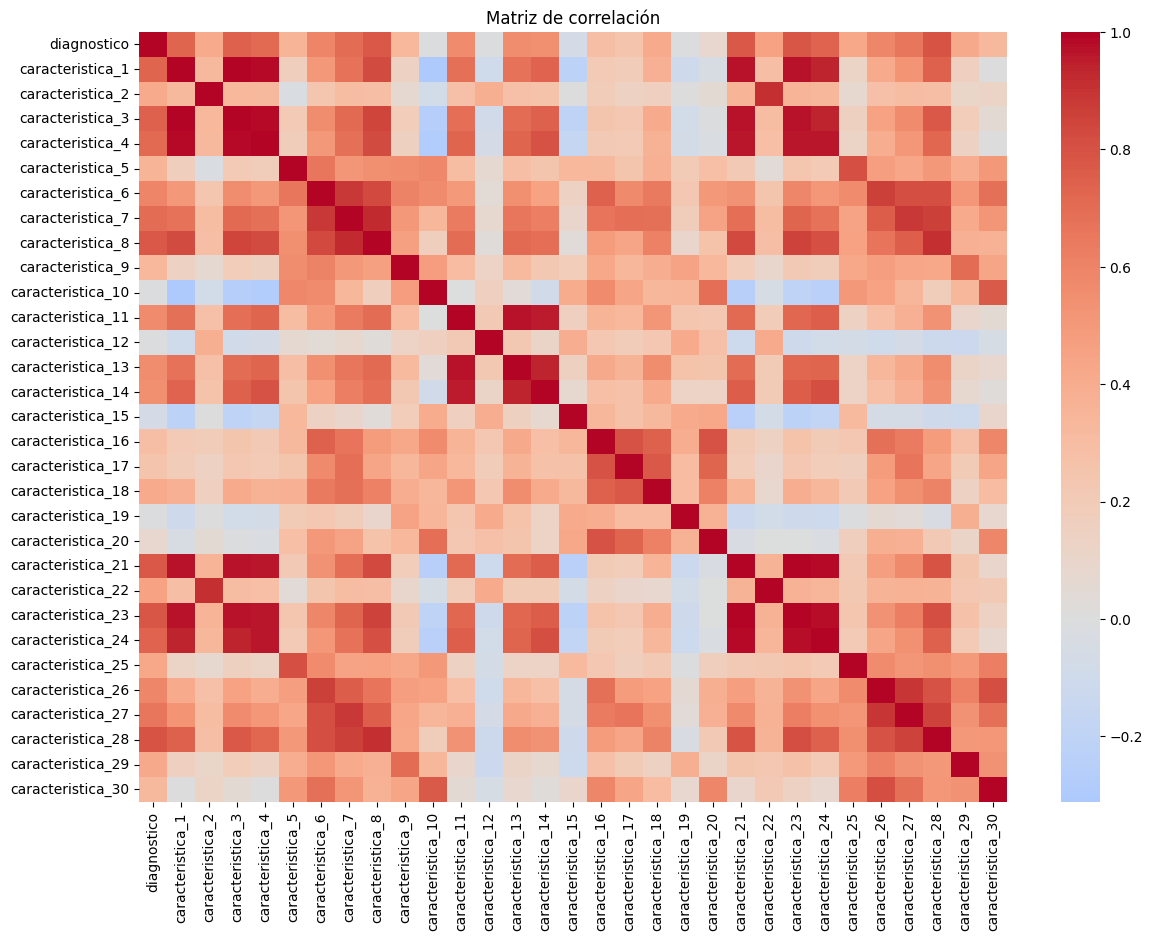

In [ ]:
# Correlation analysis
plt.figure(figsize=(14, 10))
matriz_corr = df.corr(numeric_only=True)
sns.heatmap(matriz_corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación muestra la relación lineal entre las diferentes variables del dataset.
Se puede observar que varias características presentan correlaciones altas entre sí, lo que indica que algunas variables contienen información similar o redundante.

Este comportamiento es esperado en este dataset, ya que muchas características representan mediciones relacionadas de los mismos atributos del tumor.
Por esta razón, aplicar técnicas de reducción de dimensionalidad como **PCA** puede ser útil para eliminar redundancias y simplificar el modelo sin perder demasiada información.

In [ ]:
corr_target = matriz_corr["diagnostico"].drop("diagnostico").sort_values(key=np.abs, ascending=False)
display(corr_target.head(10).to_frame(name="Correlación con diagnóstico"))

,Correlación con diagnóstico
caracteristica_28,0.793566
caracteristica_23,0.782914
caracteristica_8,0.776614
caracteristica_21,0.776454
caracteristica_3,0.742636
caracteristica_24,0.733825
caracteristica_1,0.730029
caracteristica_4,0.708984
caracteristica_7,0.696360
caracteristica_27,0.659610


En esta tabla se muestran las variables que tienen mayor correlación con el diagnóstico.
Esto indica qué características del tumor están más relacionadas con la clasificación entre benigno y maligno.

Podemos observar que algunas variables presentan correlaciones relativamente altas, como `caracteristica_28`, `caracteristica_23` y `caracteristica_8`, lo que sugiere que estas características contienen información importante para predecir el diagnóstico.

Este análisis es útil porque permite identificar qué variables tienen mayor influencia en la clasificación y ayuda a entender mejor qué información está utilizando el modelo para realizar sus predicciones.

Como queremos entrenar el modelo para predecir correctamente si un tumor es **Maligno (1)** o **Benigno (0)**, debemos eliminar del dataset la columna de diagnóstico. Sin embargo, también debemos guardarla en **y**, ya que representará el resultado que queremos obtener. Por otro lado, **X** representará nuestras variables predictoras o datos de entrenamiento para poder hacer una predicción acertada.

In [ ]:
# X serán nuestras pistas (características) y "y" será lo que queremos adivinar (diagnóstico)
X = df.drop('diagnostico', axis=1).values
y = df['diagnostico'].values


Aquí declaramos nuestros conjuntos de entrenamiento. El 80% será dedicado a que el modelo aprenda y el otro 20% será su examen, para verificar qué tan eficaz fue el aprendizaje.

Además, escalamos o estandarizamos los datos para que el modelo no le dé más peso erróneamente a diferentes columnas simplemente por su diferencia de escala o tamaño.

In [ ]:
# Dividimos los datos: 80% para que la neurona aprenda y 20% para ponerla a prueba al final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalamos (estandarizamos) los datos para facilitar el aprendizaje
scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

Aquí construimos la neurona. Primero utilizamos un contenedor donde insertamos una neurona, la cual recibe las 30 características del tumor y utiliza una función sigmoide, que transforma esa información en una probabilidad entre 0 y 1 para determinar si es benigno o maligno.

Además, es importante configurar cómo va a aprender nuestra neurona, así que utilizaremos el optimizador **Adam**, el cual actúa como una guía para el modelo, ayudando a hacer mucho más eficiente el aprendizaje. Esto se debe a que no limita al modelo a hacer ajustes de pesos de una sola forma, sino que es adaptativo: puede ajustar la dirección, ya sea positiva o negativa, así como la magnitud del ajuste, dependiendo de si el error incrementa o se reduce.



In [ ]:
# Dense(1) significa Una sola neurona. Usamos 'sigmoid' para que responda con una probabilidad entre 0 y 1.
modelo = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(30,))
])

# Configuramos cómo va a aprender la neurona
modelo.compile(optimizer='adam',
              loss='binary_crossentropy', # Función de pérdida
              metrics=['accuracy'])       # precisión (accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Aquí empieza el entrenamiento real. La neurona repasa 100 veces los datos utilizando `epochs` (épocas), es decir, en este caso repasa 100 veces los datos para facilitar el reconocimiento de patrones.

In [ ]:
print("Iniciando el entrenamiento")
# epochs=100 significa que la neurona repasará los datos 100 veces
historial = modelo.fit(X_train_escalado, y_train,
                       epochs=100,
                       validation_split=0.2, # Usa un pedacito de datos para validarse internamente
                       verbose=0)            # verbose=0 mantiene la pantalla limpia
print("Entrenamiento completado")

Iniciando el entrenamiento
Entrenamiento completado


Graficamos la curva de aprendizaje. Esta gráfica nos es de gran utilidad para verificar la eficacia del entrenamiento, ver el progreso del modelo en cada época y, por último, obtener un valor tangible en porcentaje para determinar su precisión.

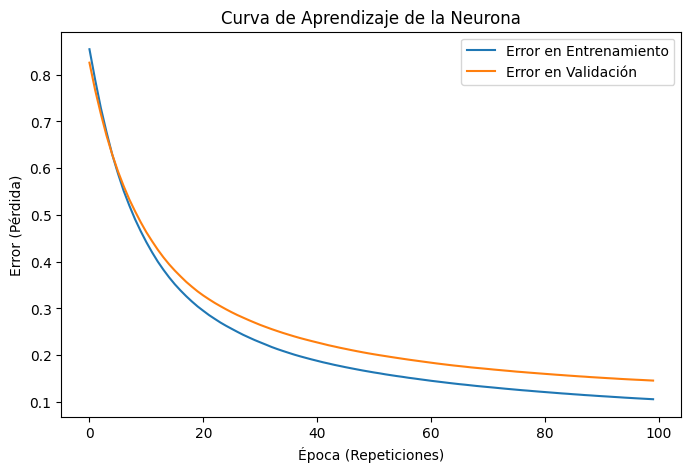

La precisión es del: 99.12%


In [ ]:
# Graficamos la Curva de Aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(historial.history['loss'], label='Error en Entrenamiento')
plt.plot(historial.history['val_loss'], label='Error en Validación')
plt.title('Curva de Aprendizaje de la Neurona')
plt.xlabel('Época (Repeticiones)')
plt.ylabel('Error (Pérdida)')
plt.legend()
plt.show()

# Evaluamos finalmente con los datos de prueba que apartamos al inicio
perdida, precision = modelo.evaluate(X_test_escalado, y_test, verbose=0)
print(f"La precisión es del: {precision * 100:.2f}%")

Podemos ver cómo, de manera progresiva y rápida, el modelo va aprendiendo los patrones y reduciendo los errores tanto de entrenamiento (curva azul) como de validación (curva naranja).

In [ ]:
# Si es mayor a 0.5, diremos que es Maligno (1). Si no, Benigno (0).
probabilidades = modelo.predict(X_test_escalado)
predicciones = (probabilidades > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


Dibujamos la matriz de confusión para determinar la cantidad de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos. De esta manera podemos asegurarnos aún más de la eficacia del entrenamiento.

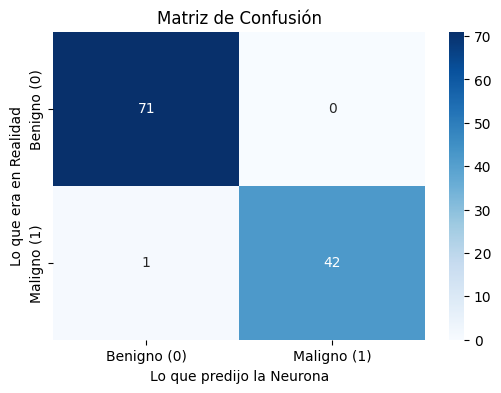

In [ ]:
cm = confusion_matrix(y_test, predicciones)

# dibujamos la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno (0)', 'Maligno (1)'],
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Lo que predijo la Neurona')
plt.ylabel('Lo que era en Realidad')
plt.show()

Como el dataset está dedicado a un problema de salud muy importante, donde en la práctica existe una diferencia entre la vida, la muerte o la velocidad de intervención sobre una persona, debemos asegurarnos de que los falsos positivos y falsos negativos sean escasos o, en el mejor de los casos, inexistentes.



---



Como mencionamos anteriormente, es de suma importancia analizar la eficacia del modelo. Para eso disponemos de varias métricas; en este caso: **Precisión, Recall, F1-Score y Especificidad**.

In [ ]:
print("\n--- REPORTE DE CLASIFICACIÓN ---")
# classification_report nos da casi todas las métricas automáticamente
reporte = classification_report(y_test, predicciones, target_names=['Benigno (0)', 'Maligno (1)'])
print(reporte)

# Extraemos los valores individuales de la matriz para calcular la Especificidad
Verdaderos_Negativos, Falsos_Positivos, Falsos_Negativos, Verdaderos_Positivos = cm.ravel()

# La Especificidad mide qué tan bueno es el modelo detectando los casos Benignos reales
especificidad = Verdaderos_Negativos / (Verdaderos_Negativos + Falsos_Positivos)
print(f"Especificidad: {especificidad:.4f} (o {especificidad * 100:.2f}%)")

# Finalmente, las instrucciones piden guardar el modelo
modelo.save('modelo_neurona_original.h5')
print("El Modelo se a guardado como 'modelo_neurona_original.h5'")


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

 Benigno (0)       0.99      1.00      0.99        71
 Maligno (1)       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

Especificidad: 1.0000 (o 100.00%)
El Modelo se a guardado como 'modelo_neurona_original.h5'


**Precisión (Precision):** Representa qué tan seguro es el modelo cuando dice que es cáncer. Si es alta, como en nuestro caso, significa que cuando la neurona indica que es maligno, casi siempre tiene razón y hay pocos falsos positivos.

**Recall (Sensibilidad o Exhaustividad):** Representa cuántos casos de cáncer logró detectar del total real. Hablando médicamente, en este campo es la métrica más importante. Un recall alto significa que casi no se escapó ningún tumor maligno, es decir, hubo pocos falsos negativos.

**F1-Score:** Es el equilibrio o “promedio inteligente” entre precisión y recall. Al ser alto, podemos decir que el modelo es sólido y fiable.

**Especificidad:** Representa qué tan bueno es detectando a personas sanas. Básicamente, mide la capacidad del modelo para identificar correctamente los casos benignos sin dar falsas alarmas.



---






Aplicamos PCA para simplificar, en caso de ser posible, los datos de entrada al modelo eliminando redundancias, logrando así una mayor eficiencia y velocidad de entrenamiento. En este caso, especificamos que debemos conservar el 95% de la varianza a través de los componentes que nos arroje el PCA.

In [ ]:
from sklearn.decomposition import PCA

# Le pedimos a PCA que nos dé los componentes necesarios para guardar el 95% de la varianza
pca = PCA(n_components=0.95)

# Transformamos nuestros datos que ya estaban escalados
X_train_pca = pca.fit_transform(X_train_escalado)
X_test_pca = pca.transform(X_test_escalado)

#Con cuántas columnas nos quedamos al final
num_componentes = pca.n_components_
print(f"Numero de componentes despues del PCA: {num_componentes}")

Numero de componentes despues del PCA: 10


Podemos observar que, de 30 componentes iniciales, redujimos los datos a solamente 10 componentes totales, conservando el 95% de la información, lo cual representa una ganancia importante para nuestro modelo.



---



Graficamos la varianza explicada para determinar la eficacia del PCA al conservar la mayor cantidad de información posible con el menor número de componentes.

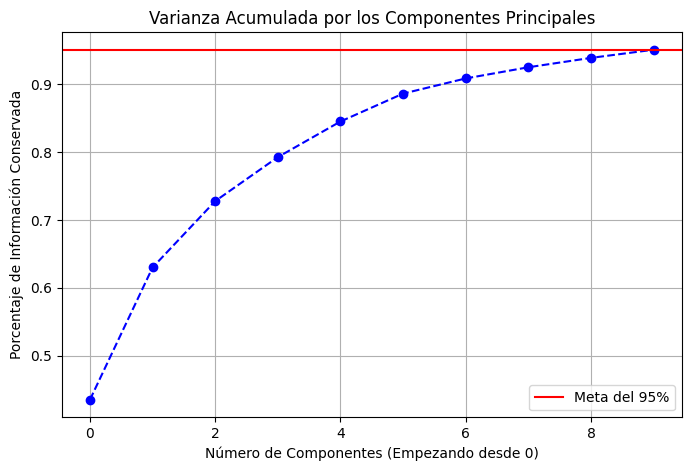

In [ ]:
# Gráfica de Varianza Explicada
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='Meta del 95%')
plt.title('Varianza Acumulada por los Componentes Principales')
plt.xlabel('Número de Componentes (Empezando desde 0)')
plt.ylabel('Porcentaje de Información Conservada')
plt.legend()
plt.grid(True)
plt.show()

Como podemos observar, al llegar a los 10 componentes mínimos logramos nuestra meta de conservar el 95% de la varianza.



---



Ahora, con nuestro “dataset reducido” o con los componentes obtenidos por PCA, creamos y entrenamos una nueva neurona de la misma manera que nuestra neurona original.

In [ ]:

print("Creando y entrenando la nueva neurona")
# Creamos el modelo. ¡Nota que la entrada (input_shape) ahora es el nuevo número de componentes!
modelo_pca = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(num_componentes,))
])

modelo_pca.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamos el modelo
historial_pca = modelo_pca.fit(X_train_pca, y_train, epochs=100, validation_split=0.2, verbose=0)

Creando y entrenando la nueva neurona


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


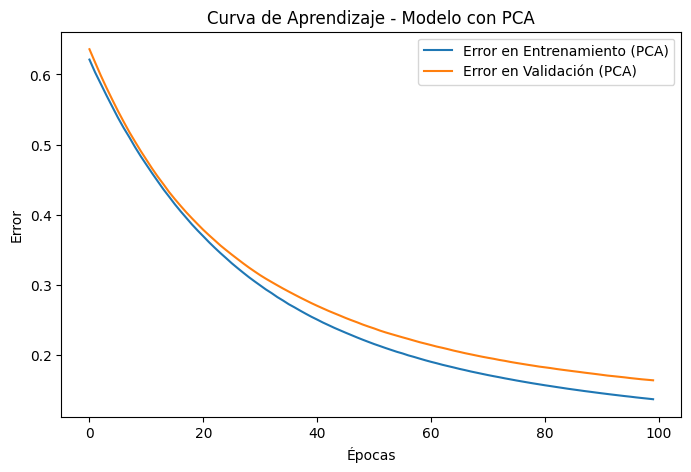

In [ ]:
# Curva de aprendizaje del modelo con PCA
plt.figure(figsize=(8, 5))
plt.plot(historial_pca.history['loss'], label='Error en Entrenamiento (PCA)')
plt.plot(historial_pca.history['val_loss'], label='Error en Validación (PCA)')
plt.title('Curva de Aprendizaje - Modelo con PCA')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()
plt.show()

Al igual que con nuestra primera neurona, podemos observar una reducción del error de entrenamiento y validación a través de las épocas utilizando PCA, con un resultado bastante similar, considerando que reducimos drásticamente el número de componentes.



---



Evaluamos el modelo basado en PCA para determinar si hubo alguna mejora tangible en la capacidad de predecir resultados correctos.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


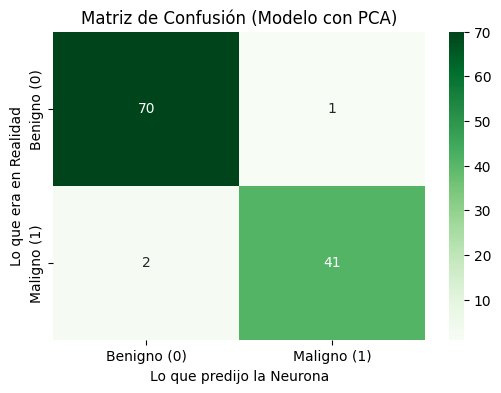

In [ ]:
# ---------------------------------------------------------
# 3. EVALUACIÓN DEL NUEVO MODELO
# ---------------------------------------------------------
probabilidades_pca = modelo_pca.predict(X_test_pca)
predicciones_pca = (probabilidades_pca > 0.5).astype(int)

# Matriz de Confusión
cm_pca = confusion_matrix(y_test, predicciones_pca)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benigno (0)', 'Maligno (1)'],
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusión (Modelo con PCA)')
plt.xlabel('Lo que predijo la Neurona')
plt.ylabel('Lo que era en Realidad')
plt.show()

Al comparar ambas matrices, observamos que el modelo basado en PCA (color verde) mantiene un rendimiento equiparable al modelo original, a pesar de utilizar solo una fracción de las variables iniciales. Esto demuestra que el Análisis de Componentes Principales eliminó con éxito la redundancia del dataset. Con base en esto, podemos concluir que el modelo al que se le aplicó PCA es preferible para su despliegue, ya que ofrece una clasificación robusta con una arquitectura mucho más ligera y eficiente.



---



In [ ]:
# Métricas finales
print("\n--- REPORTE DE CLASIFICACIÓN (MODELO PCA) ---")
print(classification_report(y_test, predicciones_pca, target_names=['Benigno (0)', 'Maligno (1)']))

VN_pca, FP_pca, FN_pca, VP_pca = cm_pca.ravel()
especificidad_pca = VN_pca / (VN_pca + FP_pca)
print(f"Especificidad (PCA): {especificidad_pca:.4f} (o {especificidad_pca * 100:.2f}%)")

# Guardamos el nuevo modelo
modelo_pca.save('modelo_neurona_pca.h5')
print("\nModelo guardado exitosamente como 'modelo_neurona_pca.h5'")


--- REPORTE DE CLASIFICACIÓN (MODELO PCA) ---
              precision    recall  f1-score   support

 Benigno (0)       0.97      0.99      0.98        71
 Maligno (1)       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Especificidad (PCA): 0.9859 (o 98.59%)

¡Modelo guardado exitosamente como 'modelo_neurona_pca.h5'!


Aunque el modelo original es ligeramente superior para detectar tumores malignos (Recall 0.98 vs 0.95), el modelo con PCA es mucho más eficiente. En computación, procesar 30 variables consume más energía y memoria que procesar unas pocas. Si tuviéramos millones de pacientes, el modelo con PCA sería el ganador por su rapidez y ligereza.

# **Conclusiones**:



Conclusión Patricio:
Para mí, lo más importante de este proyecto fue entender la magnitud del mismo, ya que el dataset se encuentra en un contexto médico de alta impacto: estamos creando un modelo que predice si una persona tiene o no un tumor maligno. En pocas palabras, si esto fuera una aplicación de campo, seríamos responsables hasta cierto punto de la vida de otras personas a través de la eficacia de este modelo.

Fue fundamental no solo realizar las dos versiones del modelo (con y sin PCA), sino comparar y determinar cuál es mejor para nuestra aplicación. Al analizar las métricas, nos dimos cuenta de que, aunque el PCA es más eficiente y simple de ejecutar, conlleva la desventaja de perder un poco de precisión. Esto me puso a pensar sobre que esa pequeña diferencia podría representar, en el peor de los casos, la diferencia entre la vida y la muerte de un paciente.

Concluyo que el uso de una sola neurona es un recordatorio de la belleza de la simplicidad, algo que para mi encapsula perfectamente el propocito de la ingenieria, el modelo de una sola nuerona es una herramienta poderosa que, cuando se apoya de un preprocesamiento riguroso y una selección estratégica de componentes (PCA), ofrece resultados de alto nivel. Este ejercicio reforzó mi criterio sobre el equilibrio entre la eficiencia computacional y la ética de tratar con vidas humanas, dándome una base sólida para diseñar soluciones tecnológicas que sean tan precisas en sus números como responsables en su aplicación real.

Conclusión Adrián:

En este proyecto aplicamos un modelo de una sola neurona para clasificar tumores como benignos o malignos usando el dataset de cáncer de mama. A lo largo del proceso se realizaron pasos importantes como limpiar los datos, preparar las variables, entrenar el modelo y evaluar su desempeño con diferentes métricas.

Algo interesante fue ver que incluso un modelo muy simple puede obtener buenos resultados cuando los datos están bien preparados. La neurona logró aprender patrones del dataset y hacer predicciones con bastante precisión.

También probamos aplicar PCA para reducir la cantidad de variables. Esto permitió simplificar el modelo sin perder mucha información, ya que el desempeño se mantuvo muy similar al del modelo original, aunque con una dimensionalidad mucho menor por lo que lo termina haciendo más rápido de utilizar.

Link al Repositorio en Github de Adrián: https://github.com/AdrianGM04/IA2-Tarea4

Link al Repositorio en Github de Patricio: https://github.com/Patrashka/SingleNeuronNetworkWithAndWithoutPCA